# Le Biais du Survivant en Crypto Trading

Ce notebook illustre le **biais du survivant** en analysant tous les actifs qui sont passés dans le Top 30 des cryptomonnaies depuis 2020.

**Concept clé** : Quand on analyse uniquement les actifs actuellement dans le top 30, on ignore tous ceux qui ont disparu (Terra/LUNA, FTT, etc.), créant un biais dans l'analyse des performances.

## 1. Setup et Imports

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

# Configuration style dark theme
plt.style.use('dark_background')
sns.set_palette('husl')

## 2. Fonction pour interroger l'API CoinMarketCap

In [2]:
def get_top_n_historical(date_str, top_n=30, exclude_tags=None):
    """
    Récupère le top N des cryptos par market cap à une date donnée.
    
    Parameters:
    -----------
    date_str : str
        Date au format 'YYYY-MM-DD'
    top_n : int
        Nombre de cryptos à récupérer (default: 30)
    exclude_tags : list
        Tags à exclure (ex: ['stablecoin', 'wrapped-tokens'])
    
    Returns:
    --------
    pd.DataFrame
        DataFrame avec colonnes: date, symbol, rank, market_cap, tags
    """
    url = 'https://api.coinmarketcap.com/data-api/v3/cryptocurrency/listings/historical'
    
    params = {
        'date': date_str,
        'limit': top_n * 2,  # Récupère plus pour compenser les exclusions
        'convertId': 2781,  # USD
        'sort': 'cmc_rank'
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if 'data' not in data or not data['data']:
            print(f"⚠️  Pas de données pour {date_str}")
            return pd.DataFrame()
        
        records = []
        for coin in data['data']:
            # Extraction des tags (c'est une liste de strings)
            tags = coin.get('tags', [])
            if not isinstance(tags, list):
                tags = []
            
            # Filtrage par tags (vérifier si un tag à exclure est présent)
            if exclude_tags:
                # Vérifier si un des tags à exclure est dans la liste des tags du coin
                should_exclude = False
                for exclude_tag in exclude_tags:
                    if exclude_tag in tags:
                        should_exclude = True
                        break
                if should_exclude:
                    continue
            
            # Extraction des données
            symbol = coin.get('symbol', '')
            rank = coin.get('cmcRank', 0)
            
            # Market cap
            quotes = coin.get('quotes', [])
            market_cap = quotes[0].get('marketCap', 0) if quotes else 0
            
            records.append({
                'date': date_str,
                'symbol': symbol,
                'rank': rank,
                'market_cap': market_cap,
                'tags': ','.join(tags) if tags else ''
            })
            
            # Arrêter quand on a assez de cryptos
            if len(records) >= top_n:
                break
        
        df = pd.DataFrame(records)
        print(f"✓ {date_str}: {len(df)} cryptos récupérées")
        return df
    
    except Exception as e:
        print(f"❌ Erreur pour {date_str}: {e}")
        return pd.DataFrame()

## 3. Téléchargement des données mensuelles

In [3]:
def generate_monthly_dates(start_date, end_date):
    """
    Génère une liste de dates mensuelles (1er de chaque mois).
    """
    dates = []
    current = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    
    while current <= end:
        dates.append(current.strftime('%Y-%m-%d'))
        current += relativedelta(months=1)
    
    return dates

# Configuration
START_DATE = '2021-01-01'
END_DATE = '2025-10-01'
TOP_N = 30
EXCLUDE_TAGS = ['stablecoin', 'wrapped-tokens']

# Génération des dates
dates = generate_monthly_dates(START_DATE, END_DATE)
print(f"📅 Téléchargement de {len(dates)} snapshots mensuels (du {START_DATE} au {END_DATE})")
print(f"🎯 Top {TOP_N} cryptos par market cap")
print(f"🚫 Exclusions: {', '.join(EXCLUDE_TAGS)}\n")

📅 Téléchargement de 58 snapshots mensuels (du 2021-01-01 au 2025-10-01)
🎯 Top 30 cryptos par market cap
🚫 Exclusions: stablecoin, wrapped-tokens



In [4]:
# Téléchargement des données en parallèle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

all_data = []

# Configuration du parallélisme
MAX_WORKERS = 10  # Nombre de requêtes simultanées (ajuster selon les limites de l'API)
BATCH_SIZE = 10  # Taille des lots pour afficher la progression

def download_date(date):
    """Fonction wrapper pour télécharger une date (utilisée par ThreadPoolExecutor)"""
    return get_top_n_historical(date, top_n=TOP_N, exclude_tags=EXCLUDE_TAGS)

# Téléchargement parallèle par batch
print(f"🚀 Téléchargement parallèle avec {MAX_WORKERS} workers\n")

for batch_start in range(0, len(dates), BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, len(dates))
    batch_dates = dates[batch_start:batch_end]
    
    print(f"[Batch {batch_start//BATCH_SIZE + 1}/{(len(dates)-1)//BATCH_SIZE + 1}] Processing dates {batch_start+1}-{batch_end}...")
    
    # Téléchargement parallèle du batch
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Soumettre toutes les tâches
        future_to_date = {executor.submit(download_date, date): date for date in batch_dates}
        
        # Collecter les résultats au fur et à mesure
        for future in as_completed(future_to_date):
            date = future_to_date[future]
            try:
                df = future.result()
                if not df.empty:
                    all_data.append(df)
            except Exception as e:
                print(f"  ❌ Exception pour {date}: {e}")
    
    # Petite pause entre les batches pour respecter les limites de l'API
    if batch_end < len(dates):
        time.sleep(1)

# Consolidation
df_full = pd.concat(all_data, ignore_index=True)
df_full['date'] = pd.to_datetime(df_full['date'])

print(f"\n✅ Total: {len(df_full)} enregistrements téléchargés")
print(f"📊 Cryptos uniques: {df_full['symbol'].nunique()}")

🚀 Téléchargement parallèle avec 10 workers

[Batch 1/6] Processing dates 1-10...
✓ 2021-04-01: 30 cryptos récupérées
✓ 2021-01-01: 30 cryptos récupérées
✓ 2021-09-01: 30 cryptos récupérées
✓ 2021-05-01: 30 cryptos récupérées
✓ 2021-03-01: 30 cryptos récupérées
✓ 2021-02-01: 30 cryptos récupérées
✓ 2021-10-01: 30 cryptos récupérées
✓ 2021-06-01: 30 cryptos récupérées
✓ 2021-07-01: 30 cryptos récupérées
✓ 2021-04-01: 30 cryptos récupérées
✓ 2021-01-01: 30 cryptos récupérées
✓ 2021-09-01: 30 cryptos récupérées
✓ 2021-05-01: 30 cryptos récupérées
✓ 2021-03-01: 30 cryptos récupérées
✓ 2021-02-01: 30 cryptos récupérées
✓ 2021-10-01: 30 cryptos récupérées
✓ 2021-06-01: 30 cryptos récupérées
✓ 2021-07-01: 30 cryptos récupérées
✓ 2021-08-01: 30 cryptos récupérées
✓ 2021-08-01: 30 cryptos récupérées
[Batch 2/6] Processing dates 11-20...
[Batch 2/6] Processing dates 11-20...
✓ 2021-11-01: 30 cryptos récupérées✓ 2022-06-01: 30 cryptos récupérées

✓ 2022-05-01: 30 cryptos récupérées
✓ 2022-07-01: 3

## 4. Analyse des données

In [5]:
# Aperçu des données
df_full.head(15)

,date,symbol,rank,market_cap,tags
0,2021-04-01,BTC,1,1.103378e+12,"mineable,pow,sha-256,store-of-value,state-chan..."
1,2021-04-01,ETH,2,2.279701e+11,"mineable,pow,smart-contracts,ethereum,coinbase..."
2,2021-04-01,BNB,3,5.180138e+10,"marketplace,centralized-exchange,payments,bina..."
3,2021-04-01,ADA,5,3.799435e+10,"mineable,dpos,pos,platform,research,smart-cont..."
4,2021-04-01,DOT,6,3.484977e+10,"substrate,polkadot,binance-chain,polkadot-ecos..."
5,2021-04-01,XRP,7,2.630218e+10,"medium-of-exchange,enterprise-solutions,binanc..."
6,2021-04-01,UNI,8,1.500373e+10,"decentralized-exchange,defi,dao,yield-farming,..."
7,2021-04-01,LTC,9,1.362500e+10,"mineable,pow,scrypt,medium-of-exchange,binance..."
8,2021-04-01,LINK,10,1.257731e+10,"platform,defi,oracles,smart-contracts,substrat..."
9,2021-04-01,FIL,11,1.194846e+10,"mineable,distributed-computing,filesharing,sto..."


In [6]:
# Statistiques de base
print("📈 STATISTIQUES DU BIAIS DU SURVIVANT\n")
print("="*60)

total_symbols = df_full['symbol'].nunique()
print(f"Total d'actifs passés dans le Top {TOP_N}: {total_symbols}")

# Actifs présents au début et à la fin
first_date = df_full['date'].min()
last_date = df_full['date'].max()

symbols_start = set(df_full[df_full['date'] == first_date]['symbol'])
symbols_end = set(df_full[df_full['date'] == last_date]['symbol'])

survivors = symbols_start & symbols_end
disappeared = symbols_start - symbols_end
new_entries = symbols_end - symbols_start

print(f"\nActifs présents en {first_date.strftime('%Y-%m')}: {len(symbols_start)}")
print(f"Actifs présents en {last_date.strftime('%Y-%m')}: {len(symbols_end)}")
print(f"\n🏆 Survivants (toujours dans le Top {TOP_N}): {len(survivors)}")
print(f"💀 Disparus du Top {TOP_N}: {len(disappeared)}")
print(f"🆕 Nouvelles entrées: {len(new_entries)}")

turnover_rate = (len(disappeared) / len(symbols_start)) * 100
print(f"\n📊 Taux de turnover: {turnover_rate:.1f}%")

print("\n" + "="*60)

📈 STATISTIQUES DU BIAIS DU SURVIVANT

Total d'actifs passés dans le Top 30: 92

Actifs présents en 2021-01: 30
Actifs présents en 2025-10: 30

🏆 Survivants (toujours dans le Top 30): 16
💀 Disparus du Top 30: 14
🆕 Nouvelles entrées: 14

📊 Taux de turnover: 46.7%



## 5. Création du Pivot Table pour la visualisation

In [8]:
# Création d'une matrice : symboles (lignes) × dates (colonnes)
# Valeur = 1 si présent dans le top 30, 0 sinon

# Toutes les dates
all_dates = sorted(df_full['date'].unique())

# Tous les symboles
all_symbols = sorted(df_full['symbol'].unique())

# Création de la matrice
presence_matrix = pd.DataFrame(0, index=all_symbols, columns=all_dates)

for _, row in df_full.iterrows():
    presence_matrix.loc[row['symbol'], row['date']] = 1

print(f"Matrice de présence: {presence_matrix.shape[0]} symboles × {presence_matrix.shape[1]} dates")
presence_matrix.head()

Matrice de présence: 92 symboles × 58 dates


,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,...,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
AAVE,1,1,1,1,1,1,1,1,1,0,...,1,1,1,0,0,1,1,1,1,1
ADA,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ALGO,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
APE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
APT,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,0,0,0


## 6. Visualisation Principale : Timeline du Top 30

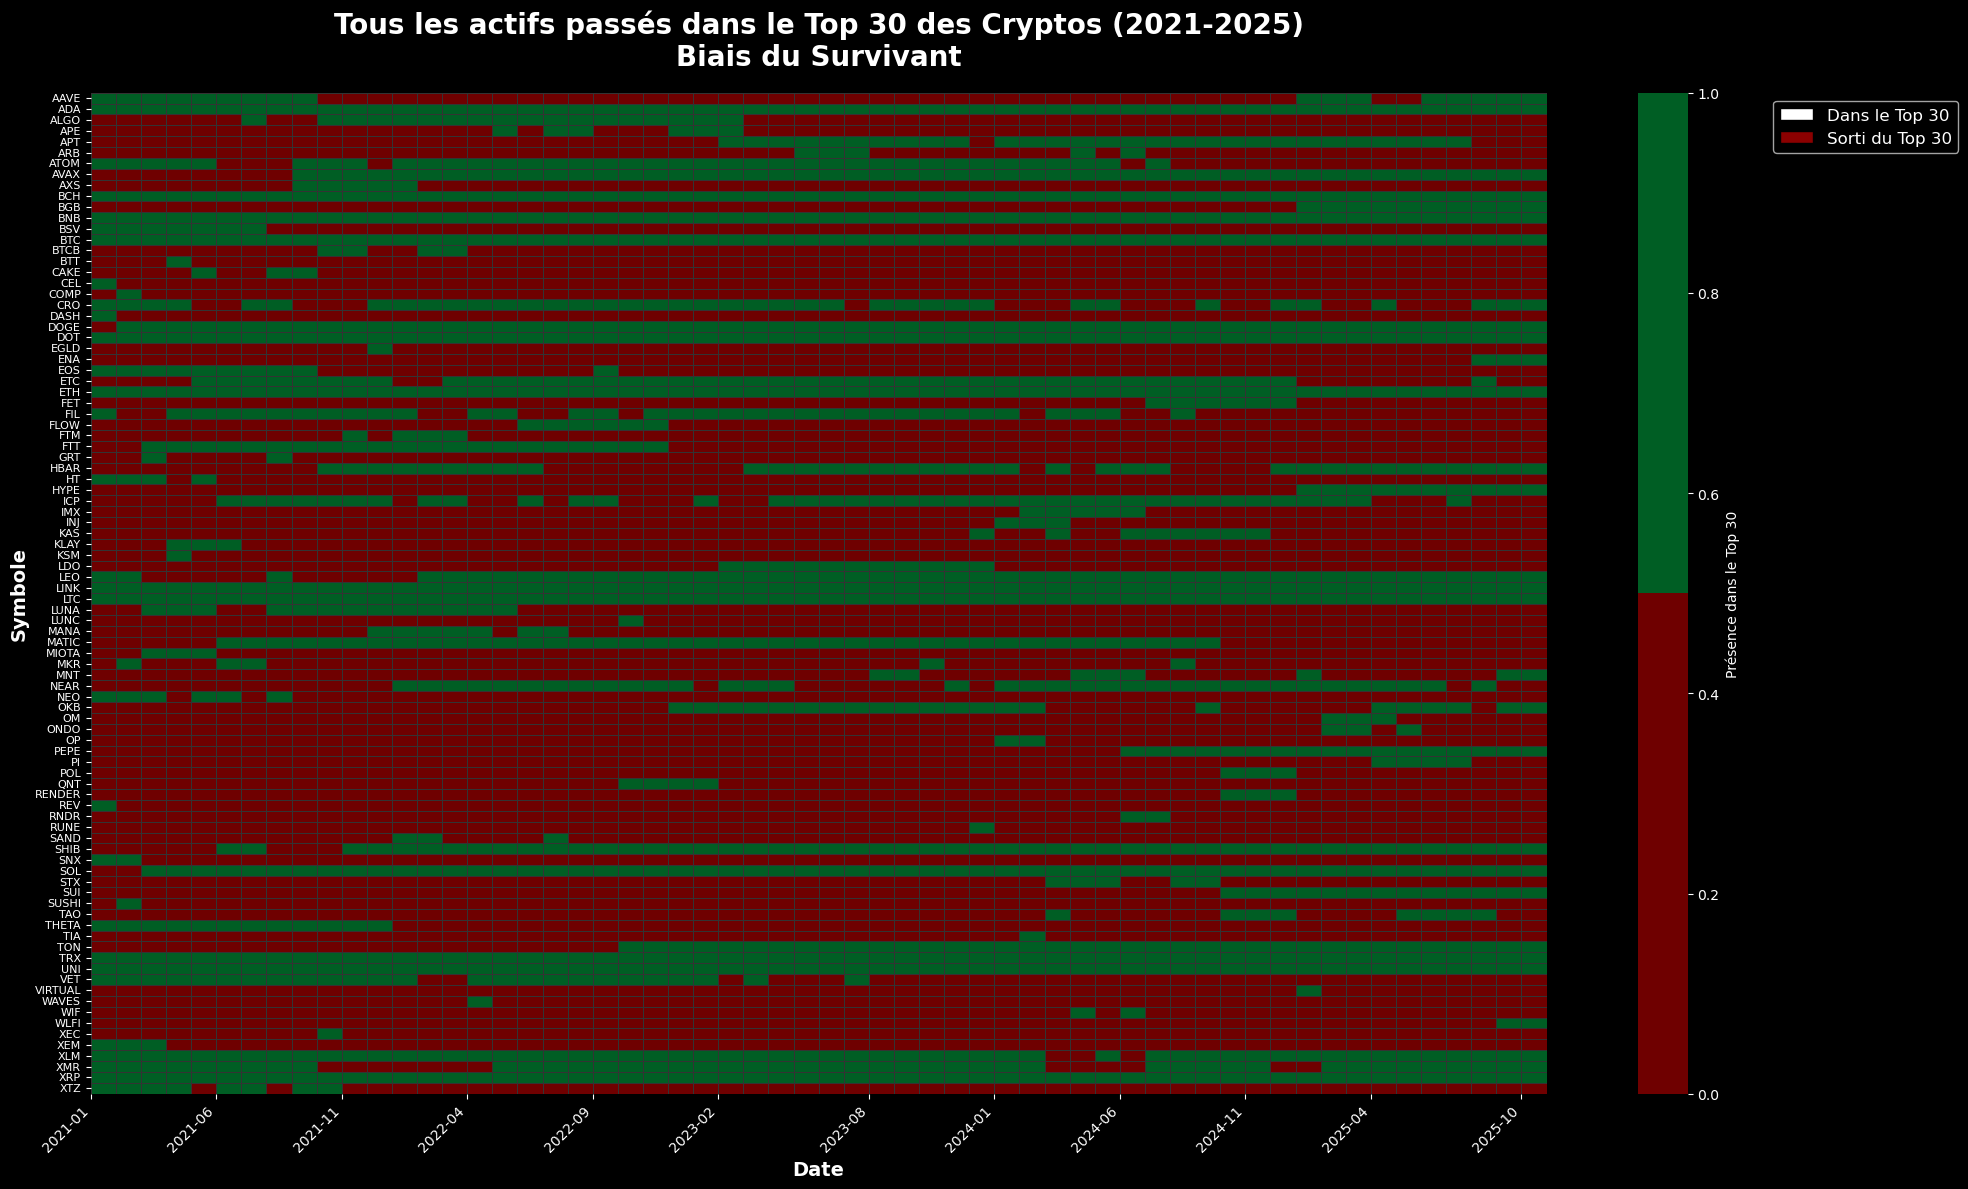

In [9]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(20, 12))

# Création du heatmap
# Blanc = présent (1), Rouge = absent (0)
cmap = sns.color_palette(["#6F0000", "#005E24"], as_cmap=True)  # Rouge foncé -> Blanc

sns.heatmap(
    presence_matrix,
    cmap=cmap,
    cbar_kws={'label': 'Présence dans le Top 30'},
    linewidths=0.5,
    linecolor='#333333',
    ax=ax,
    vmin=0,
    vmax=1,
    yticklabels=True  # Afficher tous les labels de l'axe Y
)

# Titre et labels
ax.set_title(
    f'Tous les actifs passés dans le Top {TOP_N} des Cryptos (2021-2025)\nBiais du Survivant',
    fontsize=20,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Symbole', fontsize=14, fontweight='bold')

# Format des dates sur l'axe X (tous les 6 mois)
n_ticks = 12  # Nombre de labels à afficher
tick_positions = np.linspace(0, len(all_dates)-1, n_ticks, dtype=int)
tick_labels = [all_dates[i].strftime('%Y-%m') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# Configuration de l'axe Y pour une meilleure lisibilité
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.tick_params(axis='y', which='major', labelsize=8)

# Ajout d'une légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label=f'Dans le Top {TOP_N}'),
    Patch(facecolor='#8B0000', edgecolor='black', label=f'Sorti du Top {TOP_N}')
]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.15, 1),
    fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()


## 7. Graphiques complémentaires

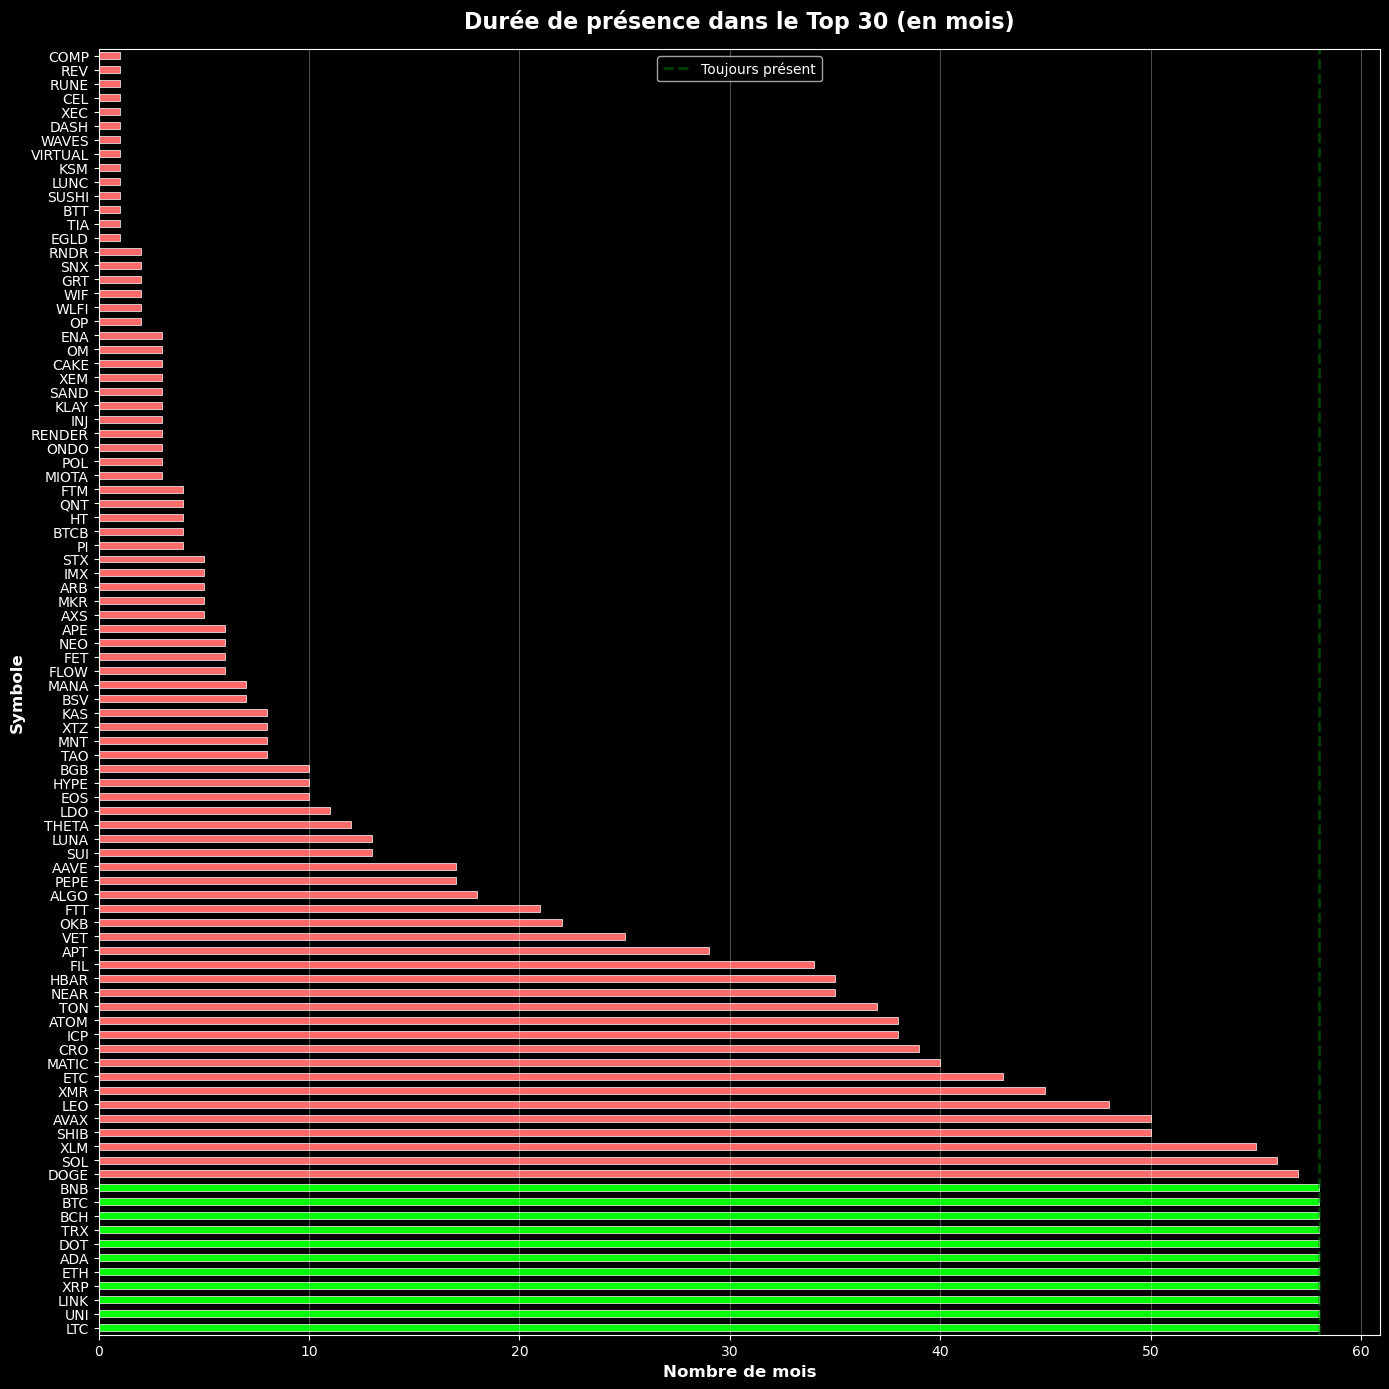

In [10]:
# Graphique 1 : Durée de présence dans le Top 30
fig, ax = plt.subplots(figsize=(14, 14))

# Calcul de la durée de présence (en mois)
presence_duration = presence_matrix.sum(axis=1).sort_values(ascending=False)

# Bar plot
colors = ['#00ff00' if x == len(all_dates) else '#ff6b6b' for x in presence_duration]
presence_duration.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title(
    f'Durée de présence dans le Top {TOP_N} (en mois)',
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Nombre de mois', fontsize=12, fontweight='bold')
ax.set_ylabel('Symbole', fontsize=12, fontweight='bold')
ax.axvline(len(all_dates), color='green', linestyle='--', linewidth=2, alpha=0.5, label='Toujours présent')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Implications pour le Trading Algorithmique

### ⚠️ Le Piège du Biais du Survivant

**Erreur classique** : Backtester une stratégie uniquement sur les cryptos actuellement dans le Top 30.

**Pourquoi c'est biaisé** :
- On ignore les actifs qui ont échoué ou les cryptos mortes ... (LUNA, FTT, etc.)
- Les performances semblent meilleures qu'elles ne l'auraient été en réalité
- On ne capture pas le risque réel de "mort" d'un actif

**Solution** :
1. Utiliser l'historique COMPLET du Top N à chaque période
2. Inclure les actifs disparus dans les backtests
3. Simuler les entrées/sorties du classement en temps réel

In [11]:
# Exemple : Impact du biais du survivant sur un backtest
print("\n💡 IMPACT DU BIAIS DU SURVIVANT SUR UN BACKTEST\n")
print("="*70)

# Scénario 1 : Backtest sur les survivants uniquement
print("\n📈 Scénario 1 - AVEC biais (survivants uniquement)")
print(f"   • Nombre d'actifs testés: {len(survivors)}")
print(f"   • Ces actifs ont 'survécu' = biais positif")
print("   • Performance surestimée ❌\n")

# Scénario 2 : Backtest sur l'univers complet
print("📉 Scénario 2 - SANS biais (univers complet historique)")
print(f"   • Nombre d'actifs testés: {total_symbols}")
print(f"   • Inclut {len(disappeared)} actifs disparus")
print("   • Performance réaliste ✅\n")


💡 IMPACT DU BIAIS DU SURVIVANT SUR UN BACKTEST


📈 Scénario 1 - AVEC biais (survivants uniquement)
   • Nombre d'actifs testés: 16
   • Ces actifs ont 'survécu' = biais positif
   • Performance surestimée ❌

📉 Scénario 2 - SANS biais (univers complet historique)
   • Nombre d'actifs testés: 92
   • Inclut 14 actifs disparus
   • Performance réaliste ✅

